# Overview Analysis From Go Artifacts

This notebook turns the Go-generated feature tables into paper-style summaries and default plots. All heavy event construction and feature extraction should already be finished by the Go pipeline. Python only performs light aggregation, filtering, and plotting on top of those outputs.

## Reading guide

This notebook reads the latest Go artifact run and now expands the default overview to cover the richer dwell-time and structure features that were already computed in Go.

- `Structure summary` still describes the pool-level linked bipartite graph.
- `Timing summary` now defaults to all value-based dwell-time metrics across pre-TC funding, pool-internal waiting, and post-withdraw release.
- `Counterparty summary` now defaults to one-hop breadth, concentration, and release-side counterparty breadth.
- `Rhythm summary` now also plots burstiness so repeated TC use is not reduced to span alone.
- `Lifecycle summary` now also plots reuse counts, single-purpose scores, and freshness shares in the filtered view.
- `Role reuse and component overlap` expose cross-pool reuse and shared-counterparty coordination that previously existed in artifacts but were not plotted by default.
- `Cross-pool folded components` remain the fast path for case-study selection.
- Every default figure is rendered as a standalone chart and is also saved under `<run_dir>/figures/02_overview_analysis/png/` and `/pdf/`.


In [ ]:
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

from tc_analysis.plots import (
    apply_default_style,
    plot_component_edge_distribution,
    plot_counterparty_cumulative_distribution,
    plot_counterparty_distribution,
    plot_gap_cumulative_distribution,
    plot_gap_distribution,
    plot_numeric_cumulative_distribution,
    plot_numeric_distribution,
    plot_structure_pie,
    plot_structure_distribution,
)

from tc_analysis.reporting import (
    OVERVIEW_COMPONENT_OVERLAP_METRICS,
    OVERVIEW_COUNTERPARTY_METRICS,
    OVERVIEW_LIFECYCLE_METRICS,
    OVERVIEW_ROLE_REUSE_METRICS,
    OVERVIEW_RHYTHM_METRICS,
    OVERVIEW_TIMING_METRICS,
    build_component_overlap_summary,
    build_counterparty_summary,
    build_lifecycle_summary,
    build_role_reuse_summary,
    build_rhythm_summary,
    build_run_overview,
    build_structure_summary,
    build_timing_summary,
    load_run_context,
    resolve_run_dir,
    select_cross_pool_case_study_components,
    select_summary_metrics,
)

pd.set_option("display.max_colwidth", 120)
apply_default_style()


def new_figure(*, figsize=(8, 4.5)):
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax


def save_figure(fig, slug, *, output_dir, saved_paths=None, dpi=200):
    png_dir = output_dir / "png"
    pdf_dir = output_dir / "pdf"
    png_dir.mkdir(parents=True, exist_ok=True)
    pdf_dir.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    png_path = png_dir / f"{slug}.png"
    pdf_path = pdf_dir / f"{slug}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    if saved_paths is not None:
        saved_paths.extend([png_path, pdf_path])
    return {"png": png_path, "pdf": pdf_path}


def plot_gap_or_placeholder(frame, *, value_col, title, ax, **kwargs):
    if value_col not in frame.columns:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Column not available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    series = pd.to_numeric(frame[value_col], errors="coerce").dropna()
    if series.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No valid observations", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    return plot_gap_distribution(frame, value_col=value_col, title=title, ax=ax, **kwargs)


def plot_gap_cdf_or_placeholder(frame, *, value_col, title, ax, **kwargs):
    if value_col not in frame.columns:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Column not available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    series = pd.to_numeric(frame[value_col], errors="coerce").dropna()
    if series.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No valid observations", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    return plot_gap_cumulative_distribution(frame, value_col=value_col, title=title, ax=ax, **kwargs)


def plot_numeric_or_placeholder(frame, *, value_col, title, x_label, ax, **kwargs):
    if value_col not in frame.columns:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Column not available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    series = pd.to_numeric(frame[value_col], errors="coerce").dropna()
    if series.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No valid observations", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    return plot_numeric_distribution(frame, value_col=value_col, title=title, x_label=x_label, ax=ax, **kwargs)


def plot_numeric_cdf_or_placeholder(frame, *, value_col, title, x_label, ax, **kwargs):
    if value_col not in frame.columns:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Column not available", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    series = pd.to_numeric(frame[value_col], errors="coerce").dropna()
    if series.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No valid observations", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    return plot_numeric_cumulative_distribution(frame, value_col=value_col, title=title, x_label=x_label, ax=ax, **kwargs)


def plot_count_bar_or_placeholder(frame, *, category_col, title, ax, color="#4C78A8"):
    if category_col not in frame.columns or frame.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, "No valid observations", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    counts = frame[category_col].fillna("missing").value_counts(dropna=False).sort_index()
    counts.plot.bar(ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(category_col.replace("_", " "))
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)
    return ax


In [ ]:
# Leave run_dir as None to inspect the newest run. Replace it with a concrete path for a pinned analysis.
run_dir = "../artifacts/runs/20260425T095232Z"

resolved_run_dir = resolve_run_dir(run_dir)
manifest, tables = load_run_context(resolved_run_dir)
figure_output_dir = Path(resolved_run_dir) / "figures" / "02_overview_analysis"
figure_output_dir.mkdir(parents=True, exist_ok=True)
saved_figures = []

print(f"Using run directory: {resolved_run_dir}")
print(f"Saving PNG figures under: {figure_output_dir / 'png'}")
print(f"Saving PDF figures under: {figure_output_dir / 'pdf'}")


Using run directory: xxx/artifacts/runs/20260425T095232Z
Saving PNG figures under: xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/png
Saving PDF figures under: xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/pdf


In [3]:
component_summary = tables["component_summary"]
edge_structure = tables["edge_structure"]
candidate_gaps = tables["candidate_gaps"]
nearest_forward_gaps = tables["nearest_forward_gaps"]
temporal_matching_gaps = tables["temporal_matching_gaps"]
window_overlap = tables["window_overlap"]
deposit_funding = tables["deposit_funding"]
withdraw_release = tables["withdraw_release"]
address_tc_rhythm = tables["address_tc_rhythm"]
address_lifecycle = tables["address_lifecycle"]
role_reuse = tables["role_reuse"]
component_counterparty_overlap = tables["component_counterparty_overlap"]
cross_pool_component_summary = tables["cross_pool_component_summary"]
cross_pool_component_membership = tables["cross_pool_component_membership"]
deposit_counterparties = tables["deposit_counterparties"]
withdraw_counterparties = tables["withdraw_counterparties"]

run_overview = build_run_overview(manifest)
structure_summary = build_structure_summary(component_summary, edge_structure)
timing_summary = build_timing_summary(tables)
counterparty_summary = build_counterparty_summary(tables)
rhythm_summary = build_rhythm_summary(tables)
lifecycle_summary = build_lifecycle_summary(tables)
role_reuse_summary = build_role_reuse_summary(tables)
component_overlap_summary = build_component_overlap_summary(tables)

cross_pool_case_candidates = select_cross_pool_case_study_components(
    cross_pool_component_summary,
    min_pool_coverage=2,
    top_k=10,
)

timing_plot_summary = select_summary_metrics(timing_summary, OVERVIEW_TIMING_METRICS)
counterparty_plot_summary = select_summary_metrics(counterparty_summary, OVERVIEW_COUNTERPARTY_METRICS)
rhythm_plot_summary = select_summary_metrics(rhythm_summary, OVERVIEW_RHYTHM_METRICS)
lifecycle_plot_summary = select_summary_metrics(lifecycle_summary, OVERVIEW_LIFECYCLE_METRICS)
role_reuse_plot_summary = select_summary_metrics(role_reuse_summary, OVERVIEW_ROLE_REUSE_METRICS)
component_overlap_plot_summary = select_summary_metrics(component_overlap_summary, OVERVIEW_COMPONENT_OVERLAP_METRICS)

window_relation_counts = (
    window_overlap["window_relation"].fillna("missing_events").value_counts(dropna=False)
    .rename_axis("window_relation")
    .reset_index(name="pair_count")
)
window_relation_counts["pair_share"] = window_relation_counts["pair_count"] / window_relation_counts["pair_count"].sum()

completion_diagnostics = pd.DataFrame(
    [
        {
            "metric": "funding_complete_approx_share",
            "share": float(deposit_funding["funding_complete_approx"].fillna(False).mean()) if not deposit_funding.empty else float("nan"),
        },
        {
            "metric": "release_complete_approx_share",
            "share": float(withdraw_release["release_complete_approx"].fillna(False).mean()) if not withdraw_release.empty else float("nan"),
        },
    ]
)

freshness_by_role = (
    address_lifecycle.groupby("role", as_index=False)
    .agg(
        address_count=("address", "size"),
        fresh_count=("is_fresh_in_filtered_view", lambda s: int(s.fillna(False).sum())),
    )
)
freshness_by_role["fresh_share"] = freshness_by_role["fresh_count"] / freshness_by_role["address_count"]

role_consistency_counts = (
    role_reuse.assign(
        cross_pool_role_consistency=role_reuse["cross_pool_role_consistency"].fillna(False).map({True: "consistent", False: "mixed"})
    )["cross_pool_role_consistency"]
    .value_counts(dropna=False)
    .rename_axis("cross_pool_role_consistency")
    .reset_index(name="address_count")
)

roles_used_counts = (
    role_reuse["roles_used"].fillna("missing")
    .value_counts(dropna=False)
    .rename_axis("roles_used")
    .reset_index(name="address_count")
)

## Run overview

Start with the run-level metadata to anchor the analysis. This is especially useful when you have multiple artifact directories and need to confirm the exact run being discussed in notes or draft figures.

In [4]:
run_overview

,run_id,schema_version,generated_at,table_count,total_rows,input_count
0,20260425T095232Z,v1alpha2,2026-04-25T09:53:09Z,20,1908499,5


## Structure summary

The structure summary is a compact description of how linked deposit and withdrawal addresses are arranged. The `structure_class` values are directly derived from the linked edge table and are a good first check for whether the data is dominated by trivial `1-to-1` links or richer multi-address components.

The bar chart and pie chart both show the same structure counts from different angles. The component edge-count plot uses a robust view because a small number of very large components can otherwise flatten the main body of the distribution.

In [5]:
structure_summary["structure_counts"]

,structure_class,edge_count
0,1-to-1,5058
1,1-to-many,549
2,many-to-1,1066
3,many-to-many,4180


In [6]:
structure_summary["component_metrics"]

,component_count,total_edges,median_edge_count,median_density,max_edge_count
0,5714,10853,1.0,1.0,644.0


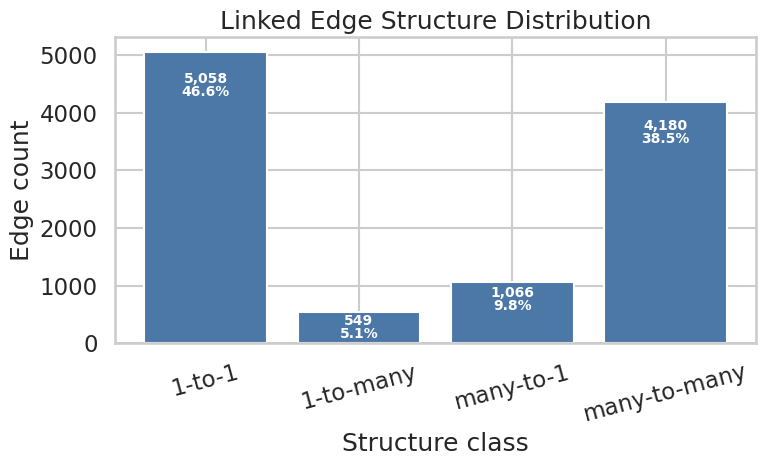

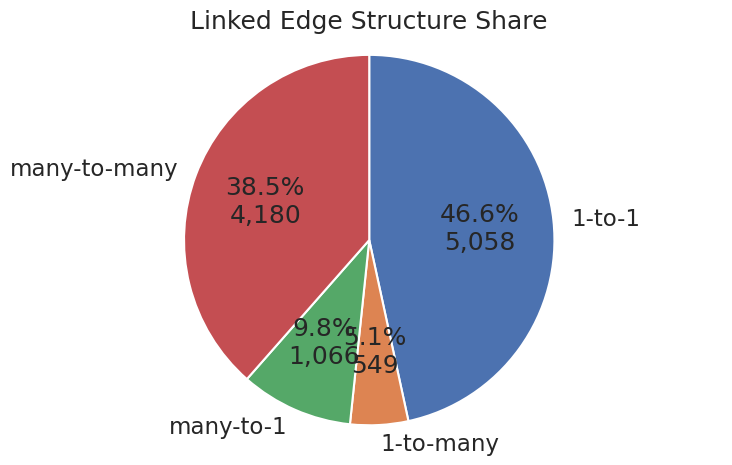

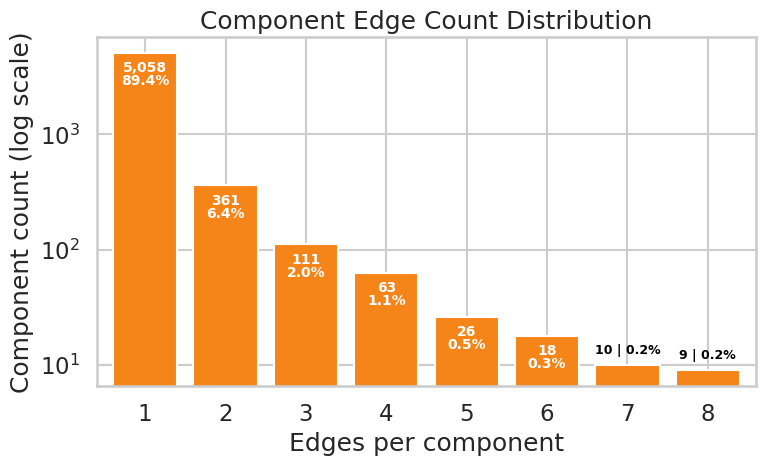

In [7]:
structure_plot_specs = [
    ("structure_distribution", lambda ax: plot_structure_distribution(edge_structure, ax=ax), (8, 5)),
    ("structure_class_share_pie", lambda ax: plot_structure_pie(edge_structure, ax=ax), (8, 5)),
    ("component_edge_count_distribution", lambda ax: plot_component_edge_distribution(component_summary, ax=ax), (8, 5)),
]

for slug, draw_fn, figsize in structure_plot_specs:
    fig, ax = new_figure(figsize=figsize)
    draw_fn(ax)
    save_figure(fig, slug, output_dir=figure_output_dir, saved_paths=saved_figures)


## Timing summary

These tables and plots summarize the richer dwell-time metrics that were already computed in Go. The notebook now defaults to all value-based timing views so pre-TC funding latency, pool-internal waiting, and post-withdraw release can be read side by side without re-matching events inside Python.

In [8]:
timing_plot_summary

,metric,count,unit,min,max,mean,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,dominant_inflow_gap_hours,27526,hours,0.000000,67627.815556,2921.538755,0.330972,2.720000,37.559861,210.551667,603.762917,1483.036944,2632.903333,3975.130000,7616.941528
1,funding_span_approx_hours,27526,hours,0.000000,70536.519167,6841.151062,1.144306,26.154167,294.068333,1086.575833,2390.014028,3973.105000,6566.241111,12463.206667,22539.127500
2,candidate_gap_hours,1550888,hours,0.000556,44892.476667,3314.410052,674.692778,1012.305000,1545.272306,2152.101056,2446.476806,2755.278611,3202.307500,4034.035000,6108.309278
3,nearest_forward_gap_hours,75922,hours,0.000556,44426.002778,3715.037925,71.986778,316.541167,673.447083,1091.569722,1651.924444,2451.197500,3465.067000,5235.257056,9920.240306
4,temporal_matching_gap_hours,25279,hours,0.006667,44676.362778,1985.273260,1.658667,71.268000,289.181222,601.527778,964.175278,1314.578722,2119.979333,3104.726611,4826.223056
5,window_overlap_hours,10853,hours,0.000000,27685.760556,156.713903,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000
6,recent_in_gap_hours,27526,hours,0.000000,41907.149167,729.276252,0.090000,0.266389,0.844861,3.045278,17.540972,64.153889,174.400000,455.967500,1549.731806
7,first_out_gap_hours,5105,hours,0.000000,52796.019722,5723.885032,0.116889,15.398056,276.126944,930.561500,2264.931389,4615.281167,6955.933000,10118.876722,12810.438944
8,half_release_gap_hours,3731,hours,0.000000,47346.625833,5581.715226,0.980000,41.556667,300.186389,1293.428889,3554.908056,5454.392778,8641.480833,10302.061944,12547.782222
9,full_release_gap_hours,3553,hours,0.000000,47346.625833,5814.010831,2.004000,71.516111,517.258056,1809.905333,4157.735278,5670.734667,9162.880889,10392.354056,12551.483000


In [9]:
display(window_relation_counts)
display(completion_diagnostics)

,window_relation,pair_count,pair_share
0,sequential,8380,0.772137
1,overlap,2268,0.208974
2,withdraw_precedes_deposit,205,0.018889


,metric,share
0,funding_complete_approx_share,0.611607
1,release_complete_approx_share,0.426275


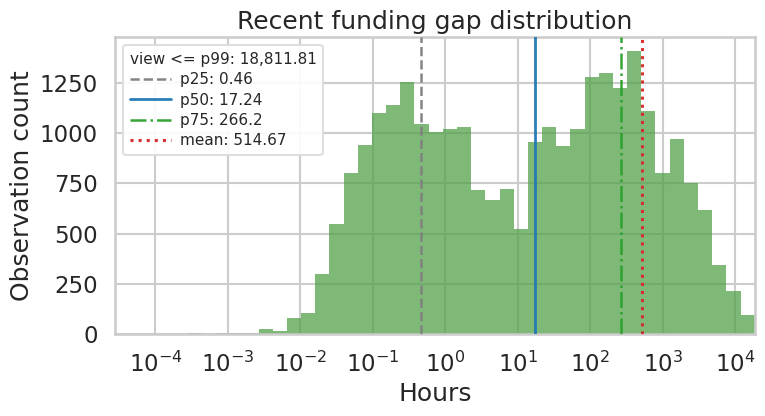

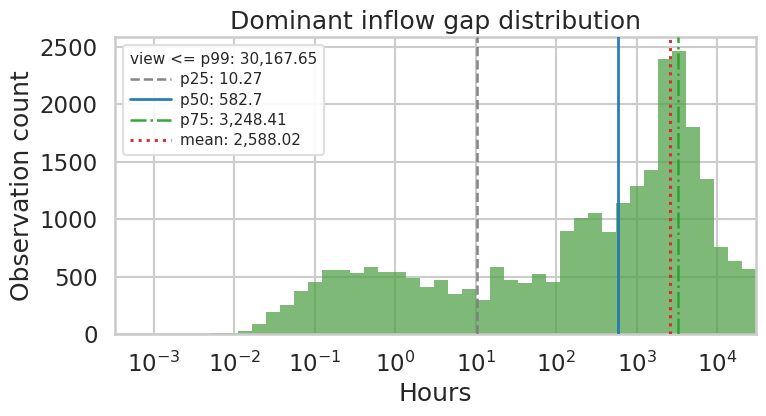

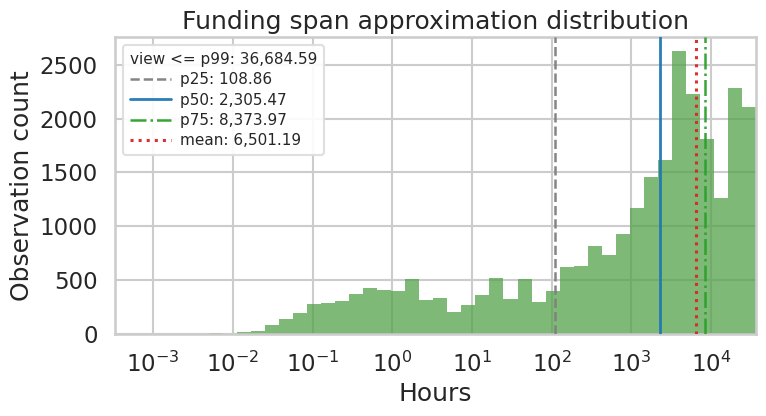

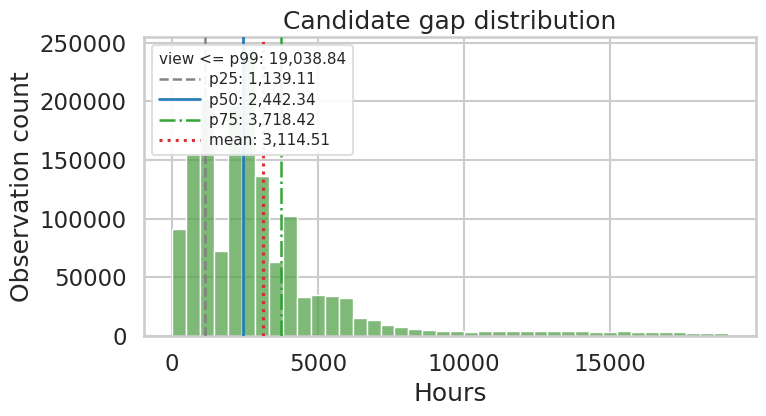

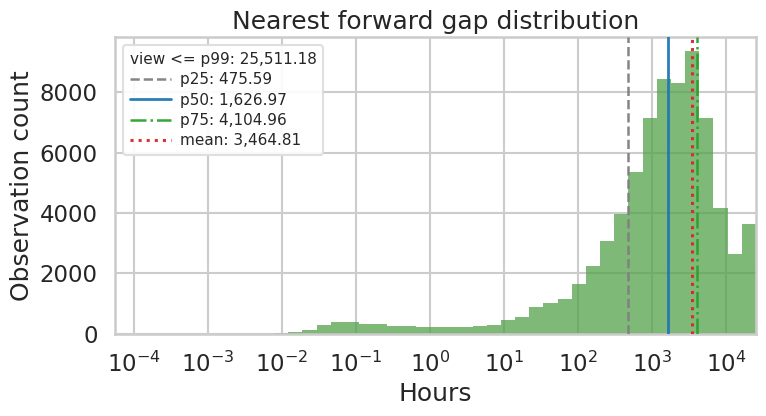

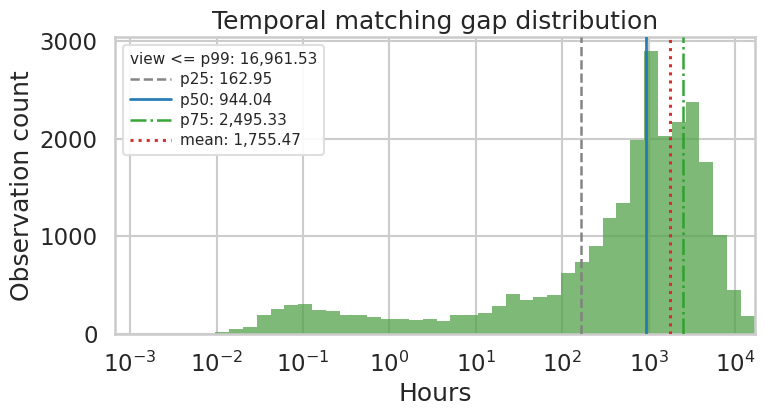

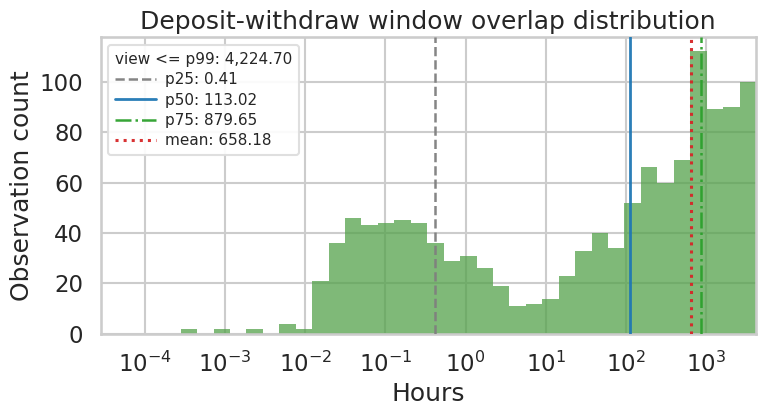

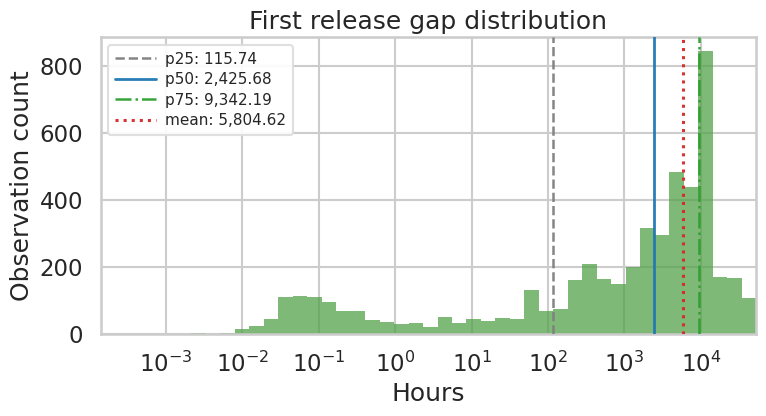

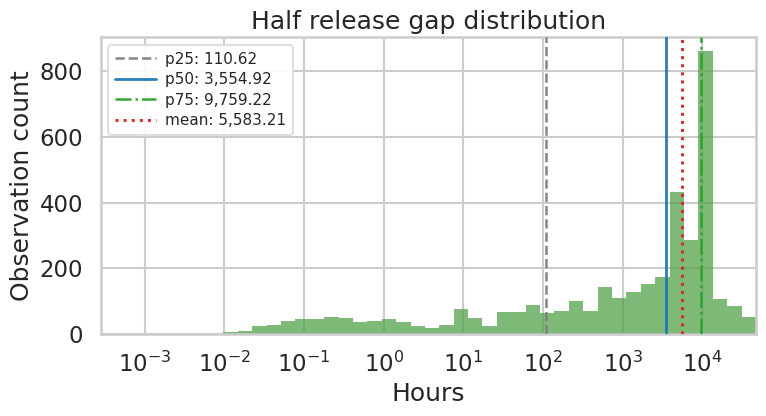

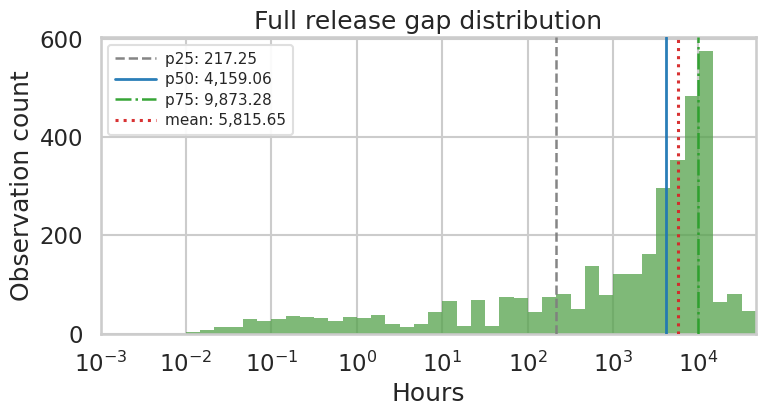

In [10]:
timing_specs = [
    ("recent_in_gap", deposit_funding, "recent_in_gap_seconds", "Recent funding gap distribution"),
    ("dominant_inflow_gap", deposit_funding, "dominant_inflow_gap_seconds", "Dominant inflow gap distribution"),
    ("funding_span_approx", deposit_funding, "funding_span_approx_seconds", "Funding span approximation distribution"),
    ("candidate_gap", candidate_gaps, "gap_seconds", "Candidate gap distribution"),
    ("nearest_forward_gap", nearest_forward_gaps, "gap_seconds", "Nearest forward gap distribution"),
    ("temporal_matching_gap", temporal_matching_gaps, "gap_seconds", "Temporal matching gap distribution"),
    ("window_overlap", window_overlap, "window_overlap_seconds", "Deposit-withdraw window overlap distribution"),
    ("first_out_gap", withdraw_release, "first_out_gap_seconds", "First release gap distribution"),
    ("half_release_gap", withdraw_release, "half_release_gap_approx_seconds", "Half release gap distribution"),
    ("full_release_gap", withdraw_release, "full_release_gap_approx_seconds", "Full release gap distribution"),
]

for slug, frame, value_col, title in timing_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_gap_or_placeholder(frame, value_col=value_col, title=title, ax=ax, legend_loc="upper left", log_left_pad_factor=10.0)
    save_figure(fig, f"timing_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


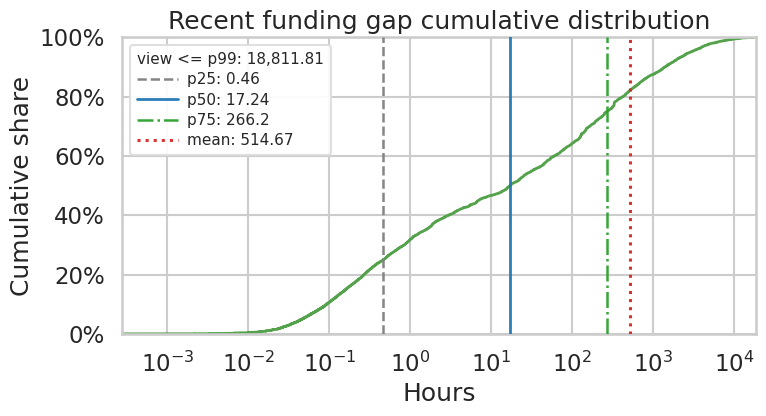

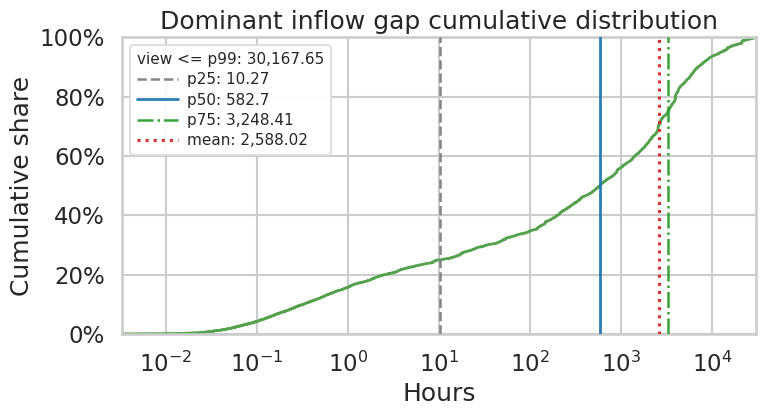

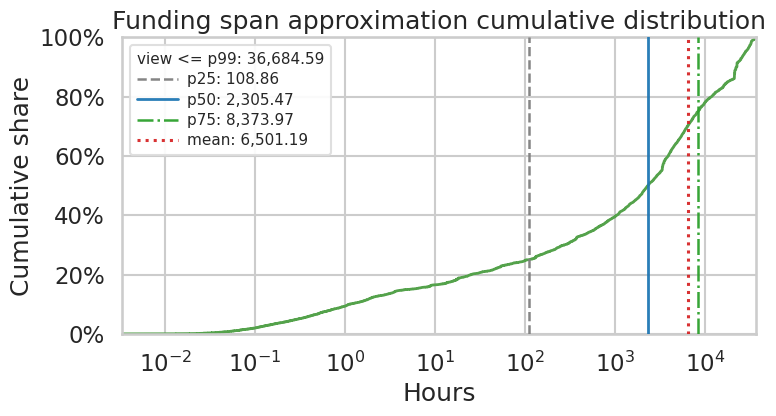

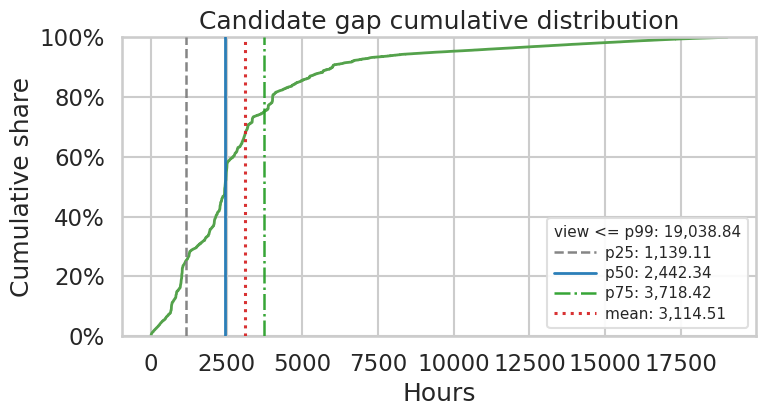

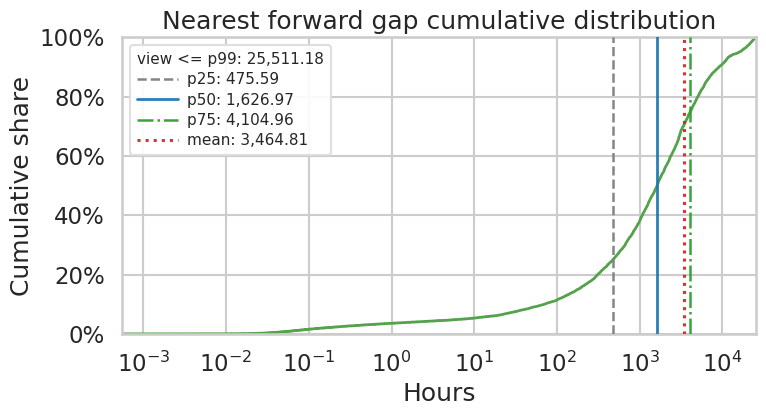

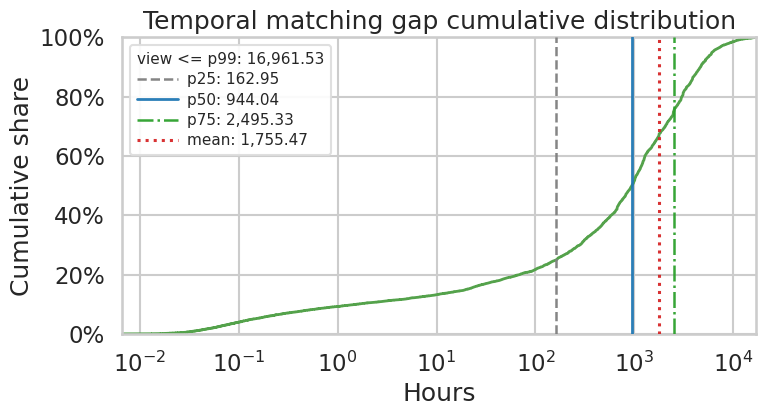

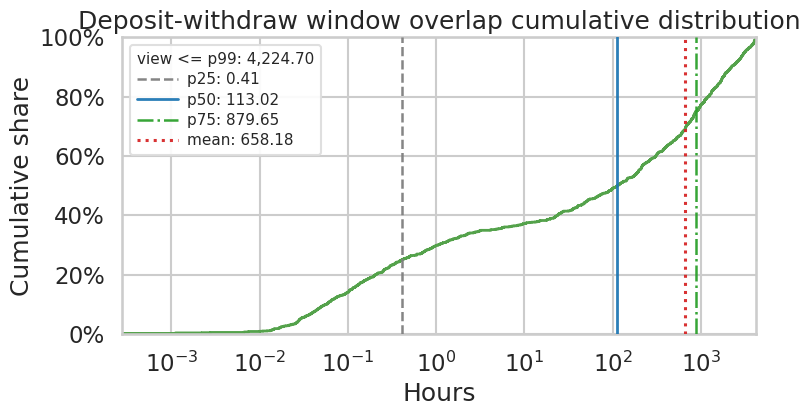

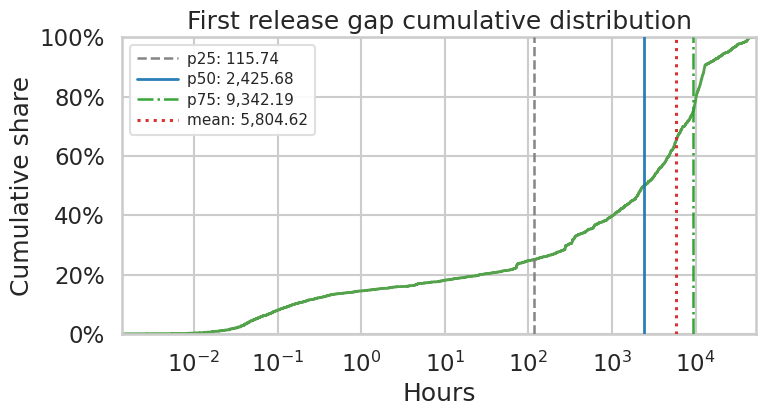

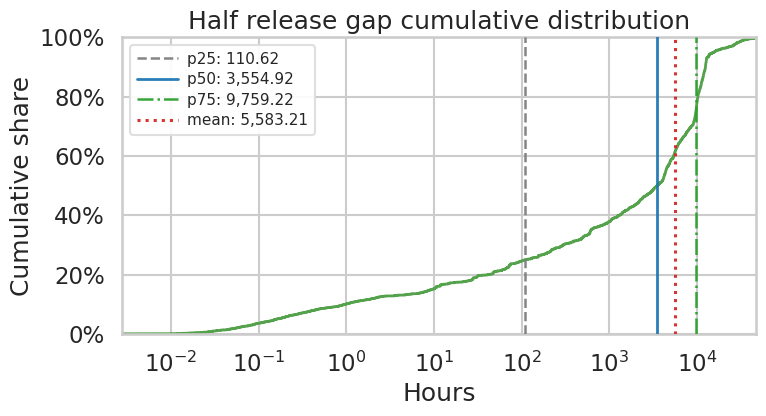

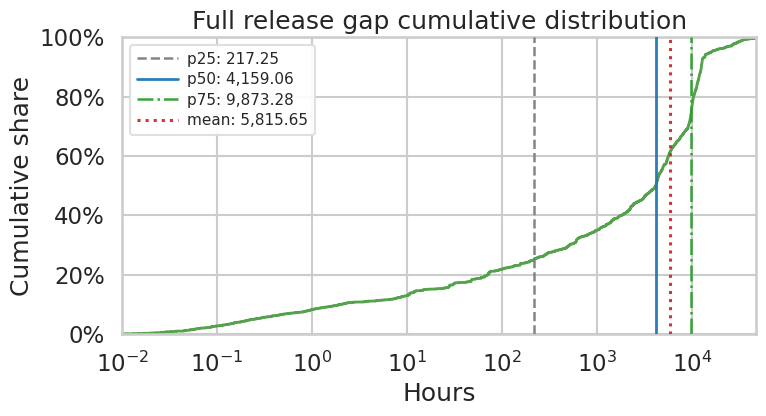

In [11]:
for slug, frame, value_col, title in timing_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    cumulative_title = title.replace("distribution", "cumulative distribution")
    plot_gap_cdf_or_placeholder(frame, value_col=value_col, title=cumulative_title, ax=ax)
    save_figure(fig, f"timing_{slug}_cdf", output_dir=figure_output_dir, saved_paths=saved_figures)


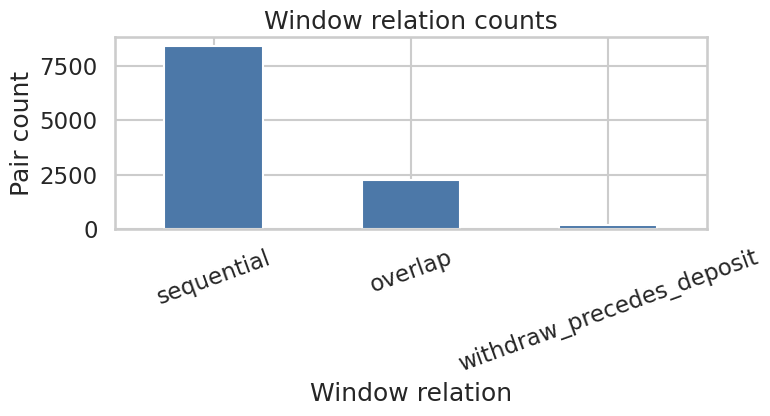

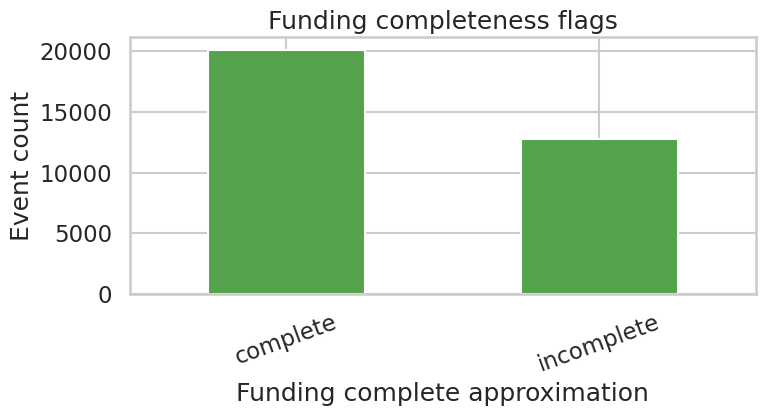

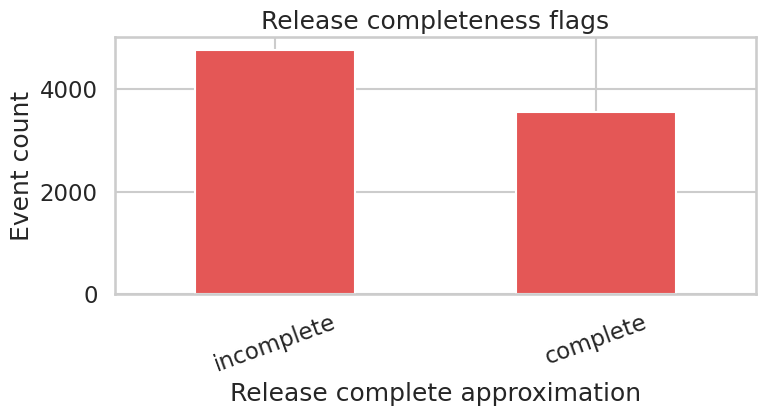

{'png': PosixPath('xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/png/timing_release_completeness_flags.png'),
 'pdf': PosixPath('xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/pdf/timing_release_completeness_flags.pdf')}

In [12]:
fig, ax = new_figure(figsize=(8, 4.5))
window_relation_counts.plot.bar(x="window_relation", y="pair_count", ax=ax, color="#4C78A8", legend=False)
ax.set_title("Window relation counts")
ax.set_xlabel("Window relation")
ax.set_ylabel("Pair count")
ax.tick_params(axis="x", rotation=20)
save_figure(fig, "timing_window_relation_counts", output_dir=figure_output_dir, saved_paths=saved_figures)

funding_complete_counts = (
    deposit_funding["funding_complete_approx"]
    .fillna(False)
    .map({True: "complete", False: "incomplete"})
    .value_counts()
    .rename_axis("funding_complete_approx")
    .reset_index(name="event_count")
)
fig, ax = new_figure(figsize=(8, 4.5))
funding_complete_counts.plot.bar(x="funding_complete_approx", y="event_count", ax=ax, color="#54A24B", legend=False)
ax.set_title("Funding completeness flags")
ax.set_xlabel("Funding complete approximation")
ax.set_ylabel("Event count")
ax.tick_params(axis="x", rotation=20)
save_figure(fig, "timing_funding_completeness_flags", output_dir=figure_output_dir, saved_paths=saved_figures)

release_complete_counts = (
    withdraw_release["release_complete_approx"]
    .fillna(False)
    .map({True: "complete", False: "incomplete"})
    .value_counts()
    .rename_axis("release_complete_approx")
    .reset_index(name="event_count")
)
fig, ax = new_figure(figsize=(8, 4.5))
release_complete_counts.plot.bar(x="release_complete_approx", y="event_count", ax=ax, color="#E45756", legend=False)
ax.set_title("Release completeness flags")
ax.set_xlabel("Release complete approximation")
ax.set_ylabel("Event count")
ax.tick_params(axis="x", rotation=20)
save_figure(fig, "timing_release_completeness_flags", output_dir=figure_output_dir, saved_paths=saved_figures)


## Counterparty summary

The counterparty tables describe breadth and concentration rather than full path reconstruction. They are useful for separating addresses that touch only one or two neighbors from addresses that fan out or aggregate over a broader one-hop neighborhood after public-address filtering.

In [13]:
counterparty_plot_summary

,metric,count,unit,min,max,mean,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,filtered_upstream_count,5890,addresses,1.0,16017.0,18.775042,1.0,2.0,2.0,3.0,5.0,7.0,11.0,19.0,36.0
1,filtered_downstream_count,1176,addresses,1.0,966.0,20.314626,1.0,1.0,2.0,4.0,5.0,8.0,12.0,22.0,47.5
2,outflow_counterparty_count,8335,addresses,0.0,268.0,3.897061,0.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0,10.0


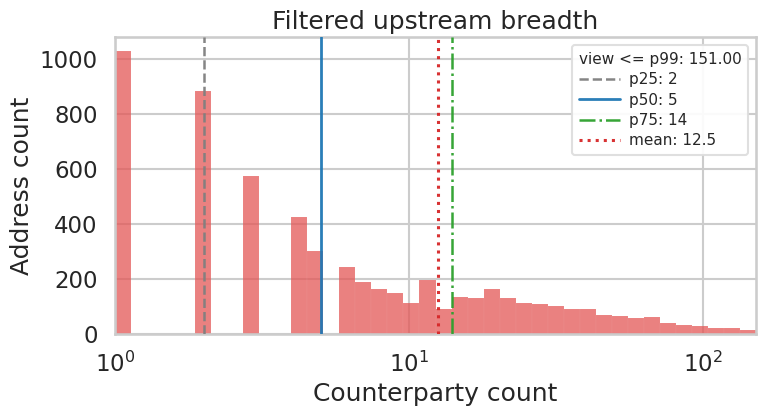

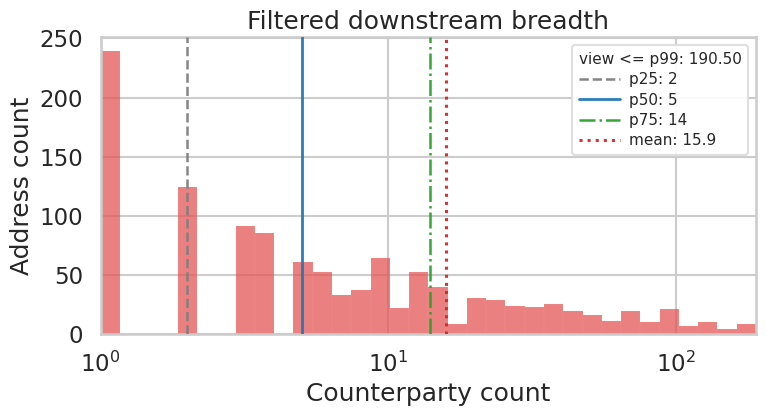

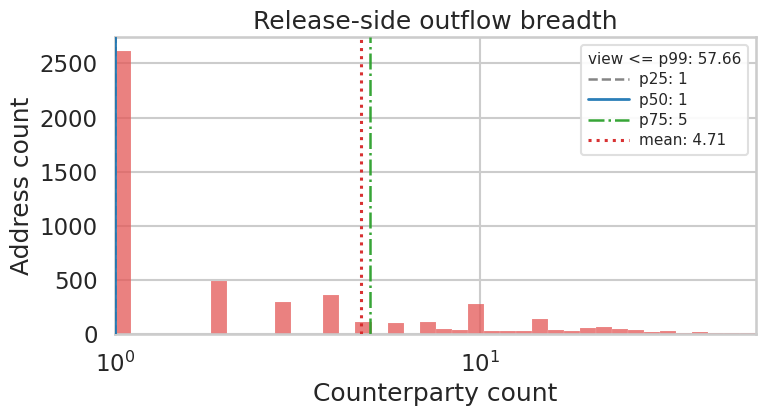

In [14]:
counterparty_breadth_specs = [
    ("filtered_upstream_breadth", deposit_counterparties, "filtered_upstream_count", "Filtered upstream breadth"),
    ("filtered_downstream_breadth", withdraw_counterparties, "filtered_downstream_count", "Filtered downstream breadth"),
    ("release_outflow_breadth", withdraw_release, "outflow_counterparty_count", "Release-side outflow breadth"),
]

for slug, frame, value_col, title in counterparty_breadth_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_counterparty_distribution(frame, value_col=value_col, title=title, ax=ax)
    save_figure(fig, f"counterparty_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


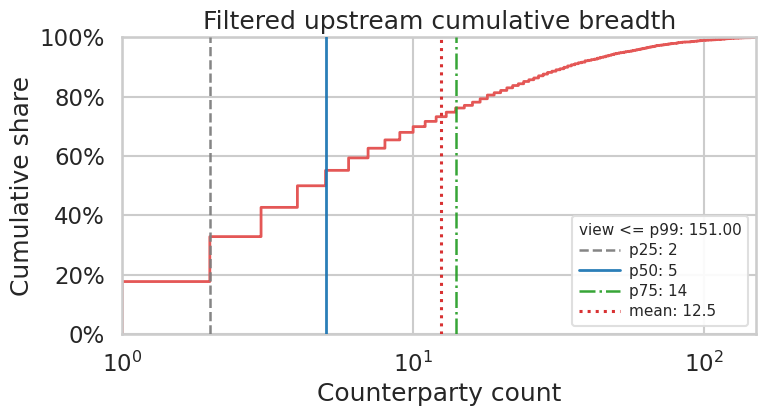

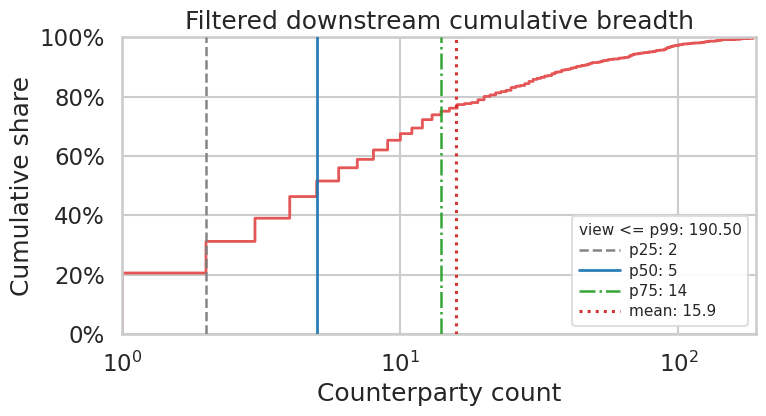

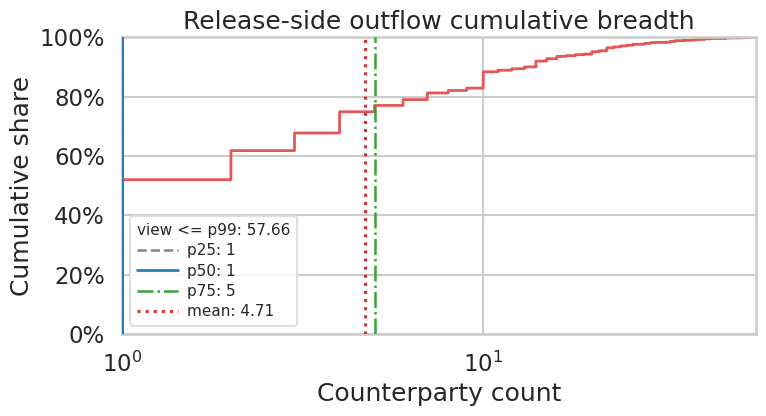

In [15]:
for slug, frame, value_col, title in counterparty_breadth_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    cumulative_title = title.replace("breadth", "cumulative breadth")
    plot_counterparty_cumulative_distribution(frame, value_col=value_col, title=cumulative_title, ax=ax)
    save_figure(fig, f"counterparty_{slug}_cdf", output_dir=figure_output_dir, saved_paths=saved_figures)


### Counterparty concentration

Breadth alone can hide whether value is concentrated in a single counterparty or spread over many. These concentration plots use HHI plus top-1 / top-3 value shares for both upstream and downstream one-hop neighborhoods.

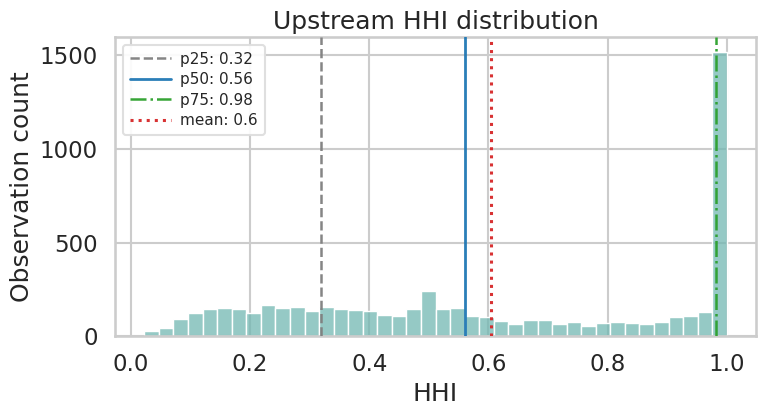

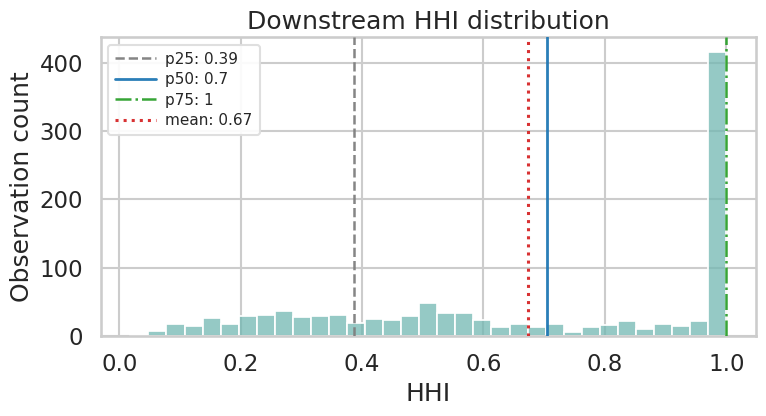

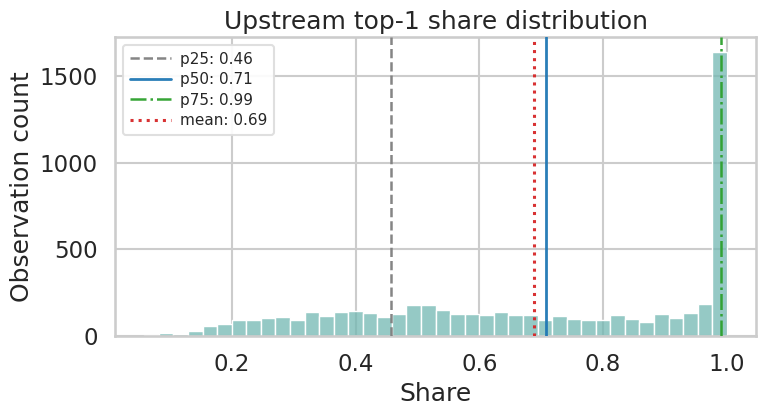

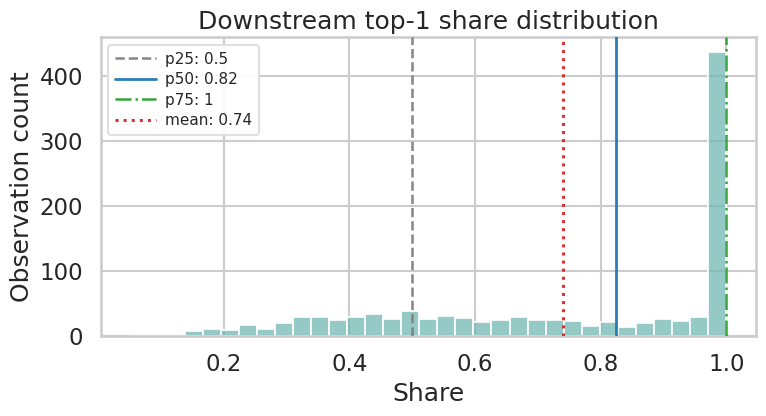

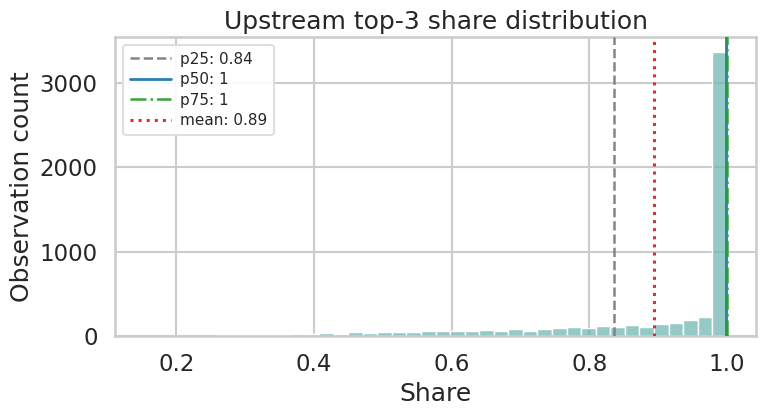

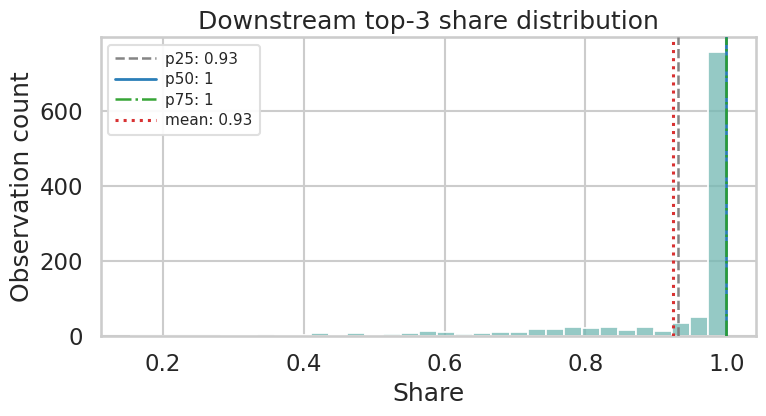

In [16]:
counterparty_concentration_specs = [
    ("upstream_hhi", deposit_counterparties, "filtered_upstream_hhi", "Upstream HHI distribution", "HHI"),
    ("downstream_hhi", withdraw_counterparties, "filtered_downstream_hhi", "Downstream HHI distribution", "HHI"),
    ("upstream_top1_share", deposit_counterparties, "filtered_upstream_top1_share", "Upstream top-1 share distribution", "Share"),
    ("downstream_top1_share", withdraw_counterparties, "filtered_downstream_top1_share", "Downstream top-1 share distribution", "Share"),
    ("upstream_top3_share", deposit_counterparties, "filtered_upstream_top3_share", "Upstream top-3 share distribution", "Share"),
    ("downstream_top3_share", withdraw_counterparties, "filtered_downstream_top3_share", "Downstream top-3 share distribution", "Share"),
]

for slug, frame, value_col, title, x_label in counterparty_concentration_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_numeric_or_placeholder(frame, value_col=value_col, title=title, x_label=x_label, ax=ax, allow_log_x=False)
    save_figure(fig, f"counterparty_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


## Rhythm summary

These plots focus on repeated TC use by the same address within one `(pool_name, role)` slice. The default overview now includes burstiness plots rather than leaving them buried in the summary table.

In [17]:
rhythm_plot_summary

,metric,count,unit,min,max,mean,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,deposit_span_hours,7334,hours,0.0,35997.192778,747.986124,0.000000,0.000000,0.000000,0.000000,0.008889,0.141167,11.630972,335.565222,2183.488722
1,withdraw_span_hours,6433,hours,0.0,39424.621667,780.910498,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328556,262.678444,2283.028556
2,deposit_mean_interarrival_hours,3803,hours,0.0,26996.374167,477.534089,0.014444,0.039167,0.160500,1.788778,18.886250,78.108704,208.712861,511.204700,1171.287032
3,withdraw_mean_interarrival_hours,2566,hours,0.0,34403.917778,552.566579,0.040208,0.089444,0.362556,8.950787,45.367670,128.199226,306.141262,637.155185,1343.766919
4,deposit_burstiness,2590,score,-1.0,0.924302,0.028573,-0.533469,-0.242856,-0.084870,-0.000942,0.057050,0.170283,0.259108,0.333322,0.451407
5,withdraw_burstiness,1710,score,-1.0,0.895598,0.043677,-0.563561,-0.291661,-0.097806,-0.000325,0.091114,0.177309,0.276189,0.379123,0.511885


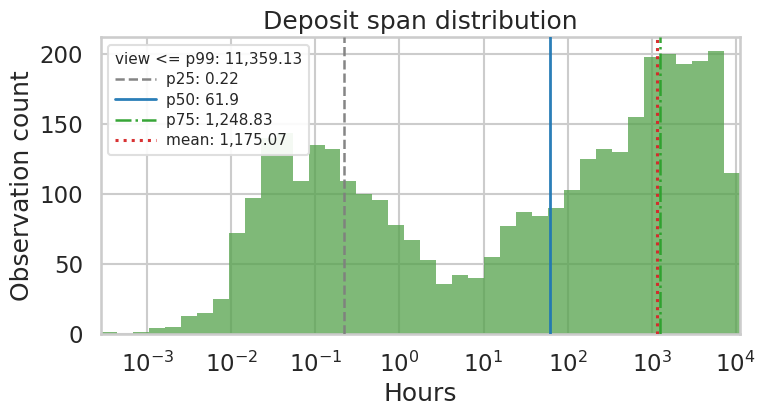

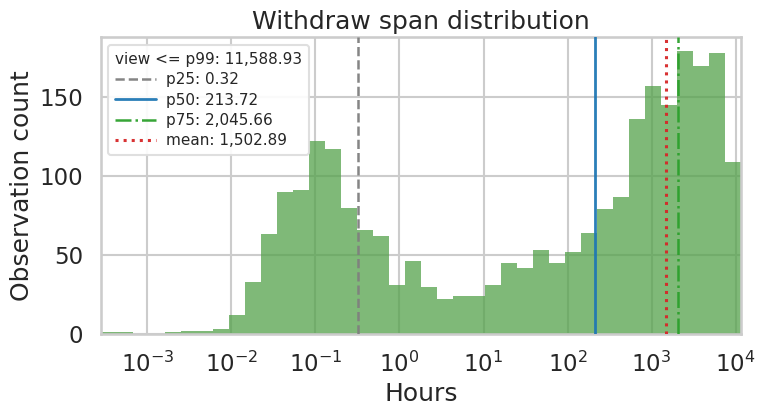

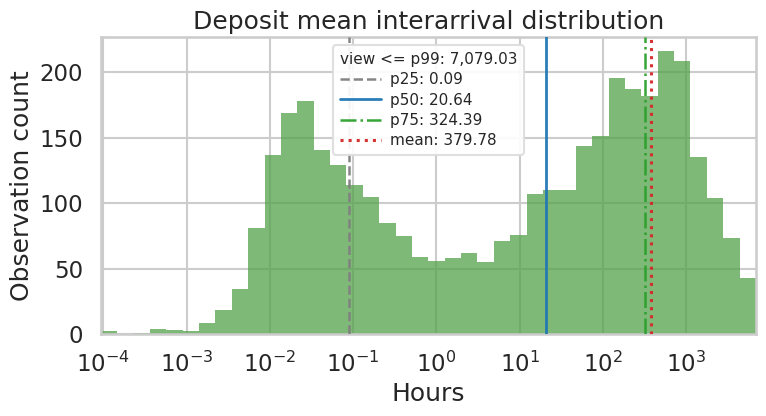

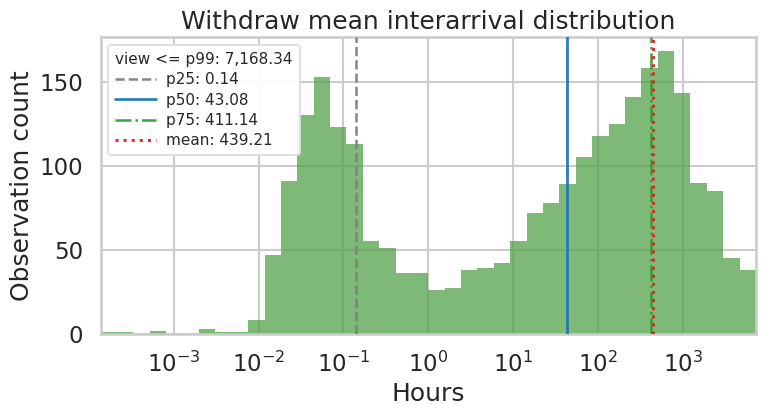

In [18]:
rhythm_gap_specs = [
    ("deposit_span", address_tc_rhythm.loc[address_tc_rhythm["role"].eq("deposit")], "span_seconds", "Deposit span distribution"),
    ("withdraw_span", address_tc_rhythm.loc[address_tc_rhythm["role"].eq("withdraw")], "span_seconds", "Withdraw span distribution"),
    ("deposit_mean_interarrival", address_tc_rhythm.loc[address_tc_rhythm["role"].eq("deposit")], "mean_interarrival_seconds", "Deposit mean interarrival distribution"),
    ("withdraw_mean_interarrival", address_tc_rhythm.loc[address_tc_rhythm["role"].eq("withdraw")], "mean_interarrival_seconds", "Withdraw mean interarrival distribution"),
]

for slug, frame, value_col, title in rhythm_gap_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_gap_or_placeholder(frame, value_col=value_col, title=title, ax=ax)
    save_figure(fig, f"rhythm_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


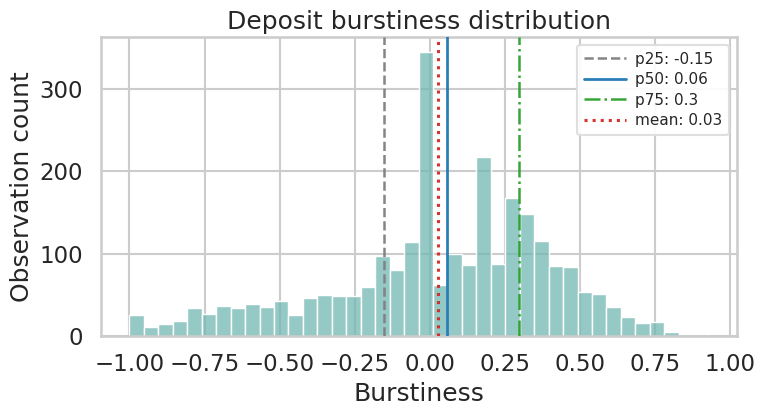

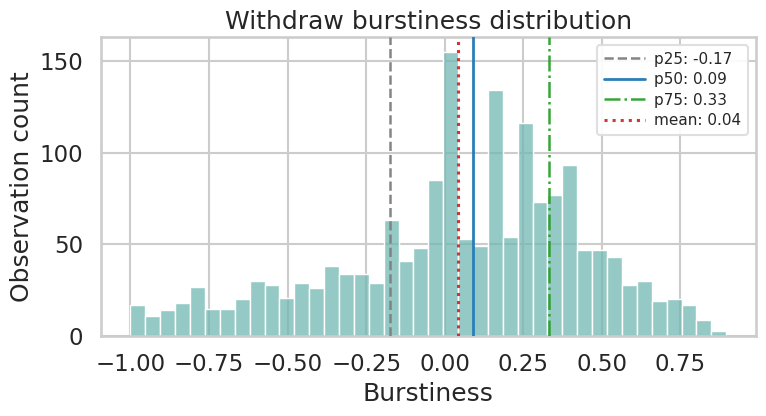

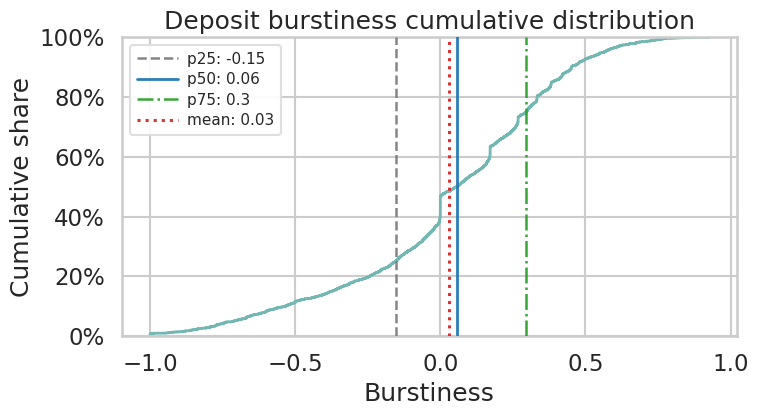

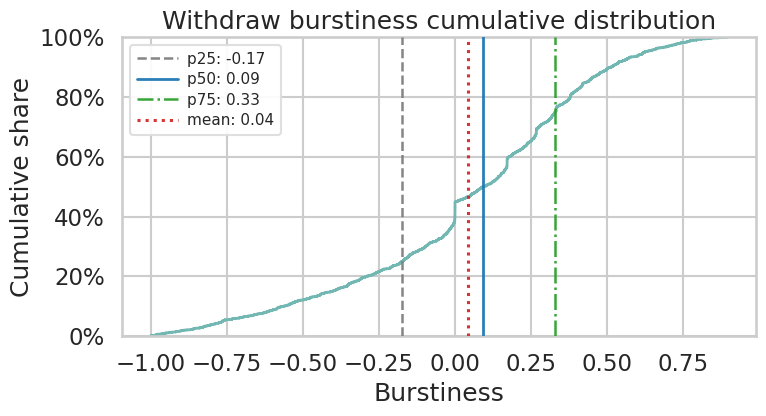

In [19]:
rhythm_burstiness_specs = [
    ("deposit_burstiness", address_tc_rhythm.loc[address_tc_rhythm["role"].eq("deposit")], "Deposit burstiness distribution", "Deposit burstiness cumulative distribution"),
    ("withdraw_burstiness", address_tc_rhythm.loc[address_tc_rhythm["role"].eq("withdraw")], "Withdraw burstiness distribution", "Withdraw burstiness cumulative distribution"),
]

for slug, frame, title, _ in rhythm_burstiness_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_numeric_or_placeholder(frame, value_col="burstiness", title=title, x_label="Burstiness", ax=ax, allow_log_x=False)
    save_figure(fig, f"rhythm_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)

for slug, frame, _, cdf_title in rhythm_burstiness_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_numeric_cdf_or_placeholder(frame, value_col="burstiness", title=cdf_title, x_label="Burstiness", ax=ax, allow_log_x=False)
    save_figure(fig, f"rhythm_{slug}_cdf", output_dir=figure_output_dir, saved_paths=saved_figures)


## Lifecycle summary

The lifecycle tables stay in the filtered non-public subgraph interpretation, so these ages and activity spans are not full-chain absolutes. The default overview now also plots reuse counts, single-purpose scores, and freshness shares instead of leaving them implicit.

In [20]:
lifecycle_plot_summary

,metric,count,unit,min,max,mean,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,deposit_filtered_age_before_first_tc_hours,6238,hours,-41520.066667,70536.519167,4362.415396,0.000000,0.122833,1.247000,41.769778,405.522222,1459.028667,3355.470806,6317.678500,17062.444472
1,withdraw_filtered_age_before_first_tc_hours,1638,hours,-45121.578056,70269.942500,1395.084175,-6294.813444,-807.148944,0.000000,0.000000,1.263333,317.542000,1696.632028,4399.790111,10117.937583
2,deposit_filtered_activity_after_last_tc_hours,6238,hours,-18460.222222,55298.706667,16187.445960,0.205194,139.012556,1542.585750,5088.830000,8740.025139,17802.680278,27862.339833,35067.801444,41271.005972
3,withdraw_filtered_activity_after_last_tc_hours,1638,hours,-25606.240833,54426.581667,12170.741602,0.000000,1.370444,230.457917,1420.955333,4193.226111,9323.986111,19636.066500,29565.410222,36988.589889
4,deposit_tc_reuse_count,6238,events,1.000000,1068.000000,5.284386,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,5.000000,10.000000
5,withdraw_tc_reuse_count,1638,events,1.000000,1210.000000,5.088523,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,7.000000
6,deposit_single_purpose_score,6238,ratio,0.000000,1.000000,0.122072,0.000000,0.000000,0.000000,0.006757,0.026316,0.068244,0.142857,0.250000,0.375000
7,withdraw_single_purpose_score,1638,ratio,0.000000,1.000000,0.137741,0.000000,0.000000,0.000000,0.000285,0.018875,0.053710,0.133333,0.250000,0.500000


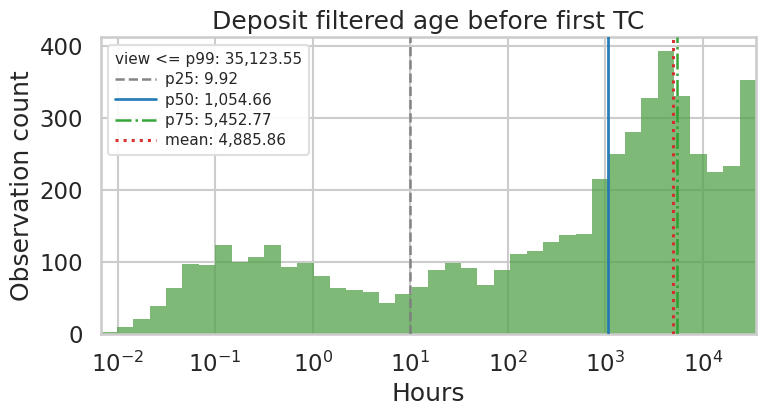

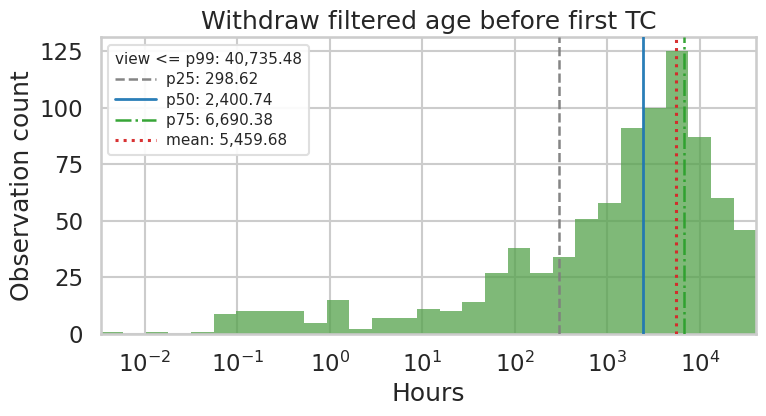

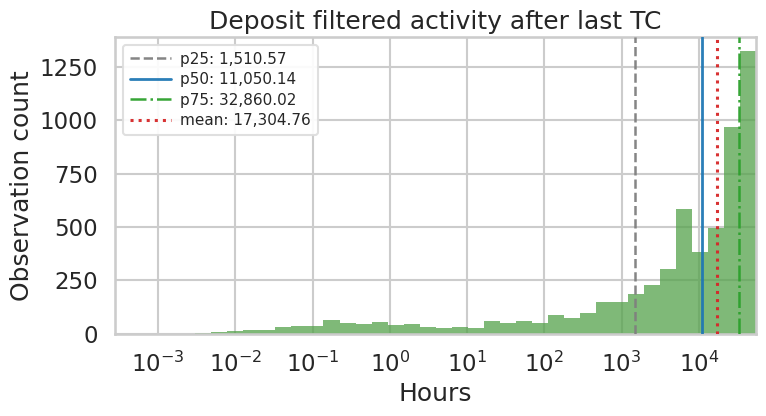

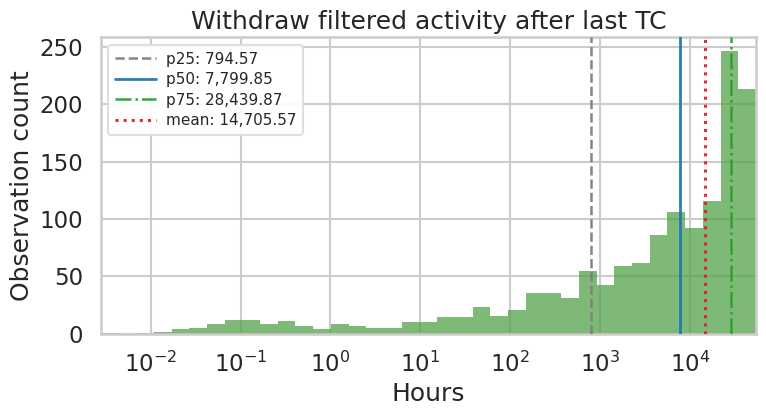

In [21]:
lifecycle_time_specs = [
    ("deposit_age_before_first_tc", address_lifecycle.loc[address_lifecycle["role"].eq("deposit")], "filtered_age_before_first_tc_seconds", "Deposit filtered age before first TC"),
    ("withdraw_age_before_first_tc", address_lifecycle.loc[address_lifecycle["role"].eq("withdraw")], "filtered_age_before_first_tc_seconds", "Withdraw filtered age before first TC"),
    ("deposit_activity_after_last_tc", address_lifecycle.loc[address_lifecycle["role"].eq("deposit")], "filtered_activity_after_last_tc_seconds", "Deposit filtered activity after last TC"),
    ("withdraw_activity_after_last_tc", address_lifecycle.loc[address_lifecycle["role"].eq("withdraw")], "filtered_activity_after_last_tc_seconds", "Withdraw filtered activity after last TC"),
]

for slug, frame, value_col, title in lifecycle_time_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_gap_or_placeholder(frame, value_col=value_col, title=title, ax=ax)
    save_figure(fig, f"lifecycle_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


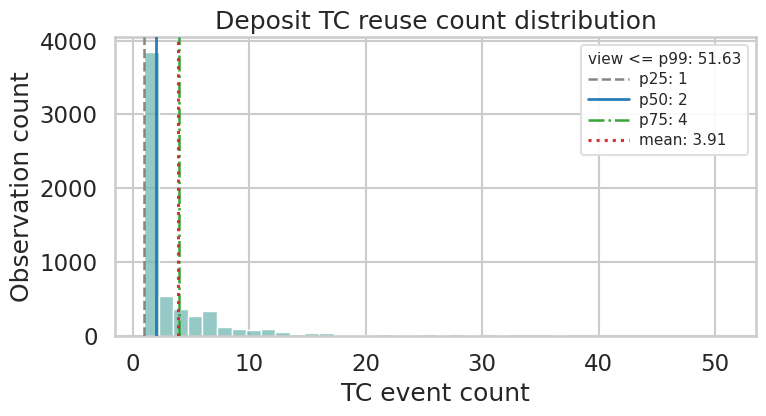

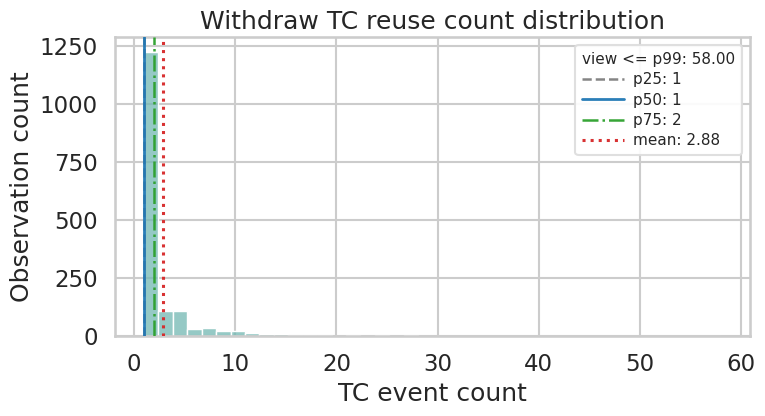

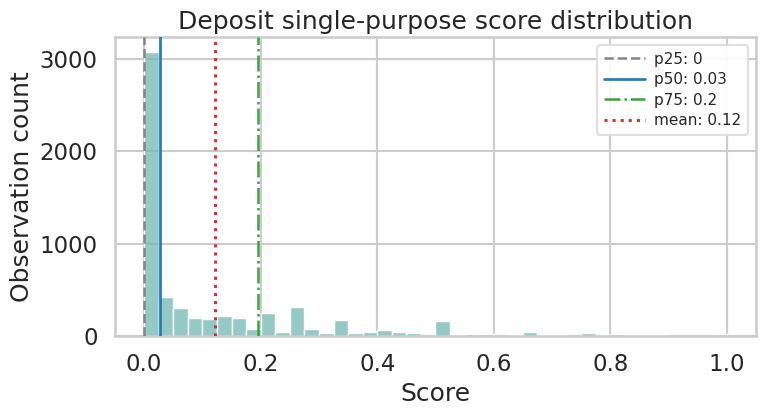

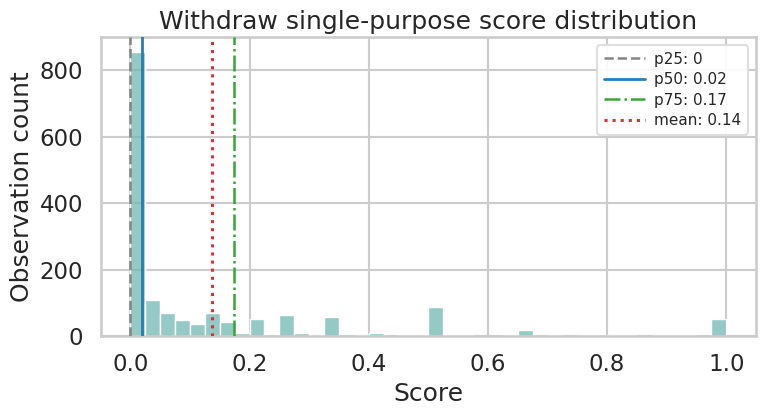

In [22]:
lifecycle_reuse_specs = [
    ("deposit_tc_reuse_count", address_lifecycle.loc[address_lifecycle["role"].eq("deposit")], "tc_reuse_count", "Deposit TC reuse count distribution", "TC event count"),
    ("withdraw_tc_reuse_count", address_lifecycle.loc[address_lifecycle["role"].eq("withdraw")], "tc_reuse_count", "Withdraw TC reuse count distribution", "TC event count"),
    ("deposit_single_purpose_score", address_lifecycle.loc[address_lifecycle["role"].eq("deposit")], "single_purpose_score", "Deposit single-purpose score distribution", "Score"),
    ("withdraw_single_purpose_score", address_lifecycle.loc[address_lifecycle["role"].eq("withdraw")], "single_purpose_score", "Withdraw single-purpose score distribution", "Score"),
]

for slug, frame, value_col, title, x_label in lifecycle_reuse_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_numeric_or_placeholder(frame, value_col=value_col, title=title, x_label=x_label, ax=ax, allow_log_x=(value_col == "tc_reuse_count"))
    save_figure(fig, f"lifecycle_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


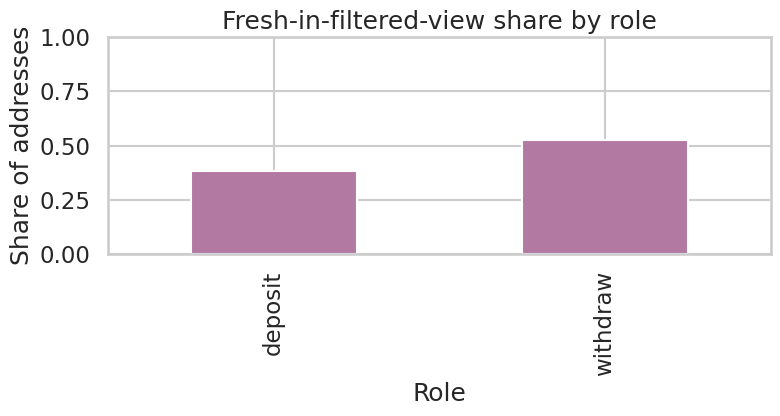

{'png': PosixPath('xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/png/lifecycle_fresh_share_by_role.png'),
 'pdf': PosixPath('xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/pdf/lifecycle_fresh_share_by_role.pdf')}

In [23]:
fig, ax = new_figure(figsize=(8, 4.5))
freshness_by_role.plot.bar(x="role", y="fresh_share", legend=False, ax=ax, color="#B279A2")
ax.set_title("Fresh-in-filtered-view share by role")
ax.set_xlabel("Role")
ax.set_ylabel("Share of addresses")
ax.set_ylim(0.0, 1.0)
save_figure(fig, "lifecycle_fresh_share_by_role", output_dir=figure_output_dir, saved_paths=saved_figures)


## Role reuse and component overlap

These features were already present in the artifact layer but were not plotted by default. They are useful for checking whether the same addresses span multiple pools and whether linked components share one-hop counterparties in ways that support coordinated-use narratives.

In [24]:
display(role_reuse_plot_summary)
display(component_overlap_plot_summary)

,metric,count,unit,min,max,mean,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,pool_diversity,7759,pools,1.0,4.0,1.170769,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
1,role_count,7759,roles,1.0,2.0,1.541307,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0
2,cross_pool_role_consistency_share,7759,share,0.0,1.0,0.458693,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


,metric,count,unit,min,max,mean,p10,p20,p30,p40,p50,p60,p70,p80,p90
0,shared_upstream_ratio,475,ratio,0.0,1.0,0.649620,0.0,0.0,0.333333,0.700000,1.000000,1.000000,1.00000,1.000000,1.000000
1,shared_downstream_ratio,402,ratio,0.0,1.0,0.043134,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
2,upstream_jaccard_similarity,475,ratio,0.0,1.0,0.128429,0.0,0.0,0.007495,0.028558,0.047619,0.076923,0.13351,0.222222,0.383265
3,downstream_jaccard_similarity,402,ratio,0.0,0.5,0.008807,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,component_counterparty_reuse,5399,ratio,0.0,1.0,0.015187,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.027027


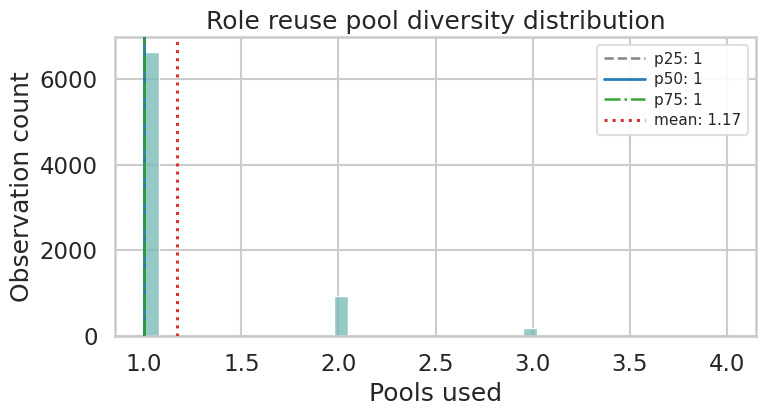

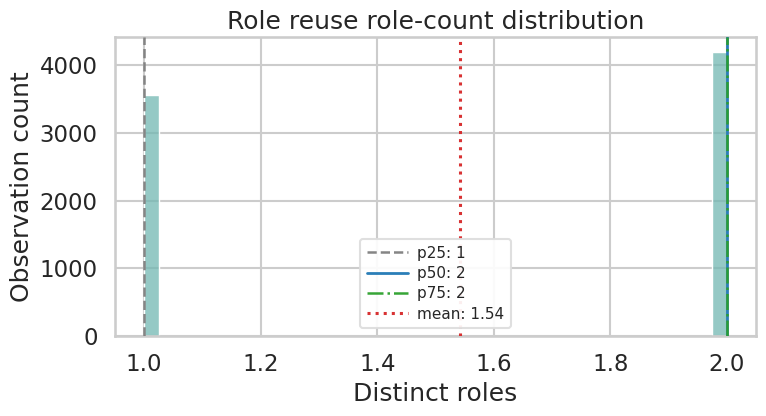

In [25]:
role_reuse_specs = [
    ("pool_diversity", "pool_diversity", "Role reuse pool diversity distribution", "Pools used", True),
    ("role_count", "role_count", "Role reuse role-count distribution", "Distinct roles", False),
]

for slug, value_col, title, x_label, allow_log_x in role_reuse_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_numeric_or_placeholder(role_reuse, value_col=value_col, title=title, x_label=x_label, ax=ax, allow_log_x=allow_log_x)
    save_figure(fig, f"role_reuse_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


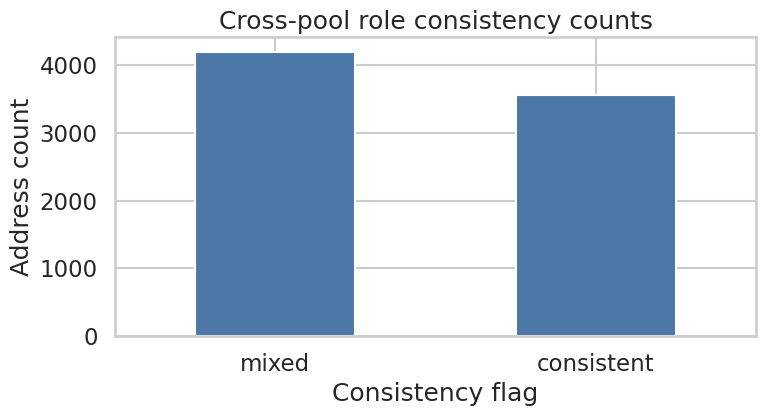

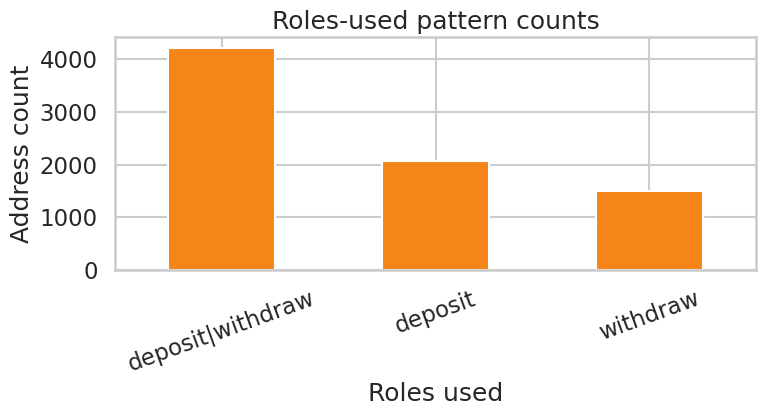

{'png': PosixPath('xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/png/role_reuse_roles_used_pattern_counts.png'),
 'pdf': PosixPath('xxx/artifacts/runs/20260425T095232Z/figures/02_overview_analysis/pdf/role_reuse_roles_used_pattern_counts.pdf')}

In [26]:
fig, ax = new_figure(figsize=(8, 4.5))
role_consistency_counts.plot.bar(x="cross_pool_role_consistency", y="address_count", ax=ax, color="#4C78A8", legend=False)
ax.set_title("Cross-pool role consistency counts")
ax.set_xlabel("Consistency flag")
ax.set_ylabel("Address count")
ax.tick_params(axis="x", rotation=0)
save_figure(fig, "role_reuse_cross_pool_role_consistency_counts", output_dir=figure_output_dir, saved_paths=saved_figures)

fig, ax = new_figure(figsize=(8, 4.5))
roles_used_counts.plot.bar(x="roles_used", y="address_count", ax=ax, color="#F58518", legend=False)
ax.set_title("Roles-used pattern counts")
ax.set_xlabel("Roles used")
ax.set_ylabel("Address count")
ax.tick_params(axis="x", rotation=20)
save_figure(fig, "role_reuse_roles_used_pattern_counts", output_dir=figure_output_dir, saved_paths=saved_figures)


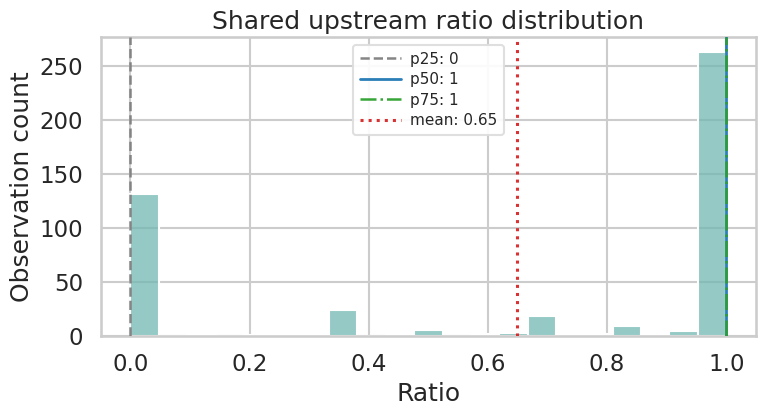

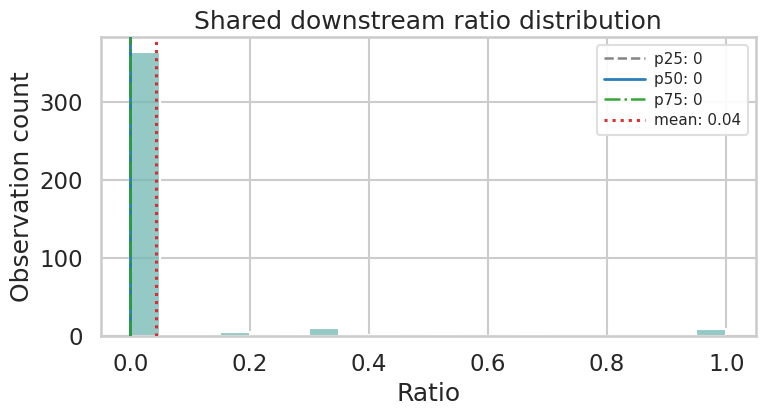

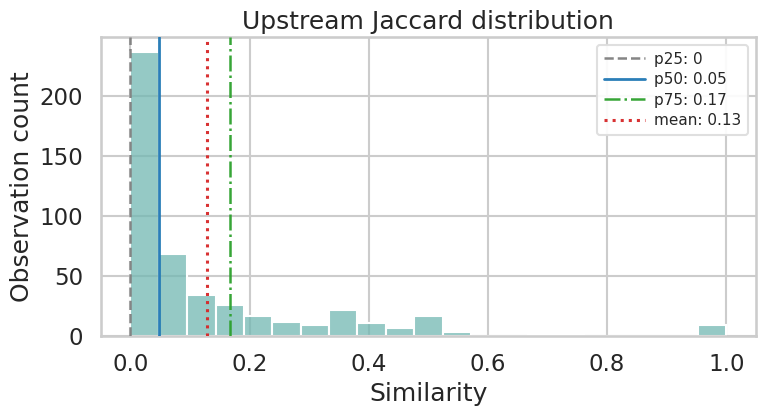

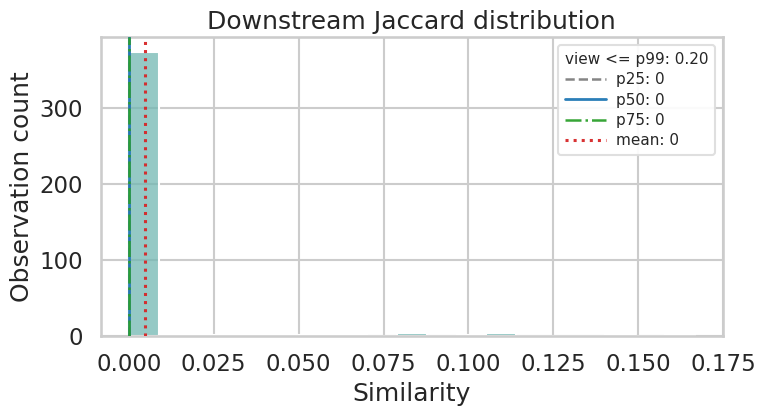

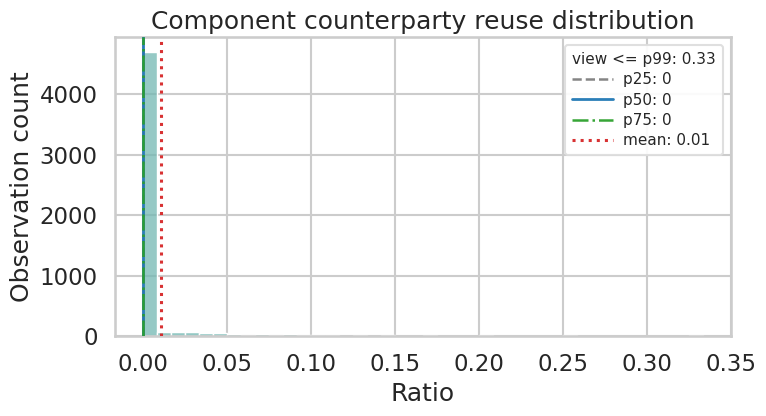

In [27]:
component_overlap_specs = [
    ("shared_upstream_ratio", "shared_upstream_ratio", "Shared upstream ratio distribution", "Ratio"),
    ("shared_downstream_ratio", "shared_downstream_ratio", "Shared downstream ratio distribution", "Ratio"),
    ("upstream_jaccard_similarity", "upstream_jaccard_similarity", "Upstream Jaccard distribution", "Similarity"),
    ("downstream_jaccard_similarity", "downstream_jaccard_similarity", "Downstream Jaccard distribution", "Similarity"),
    ("component_counterparty_reuse", "component_counterparty_reuse", "Component counterparty reuse distribution", "Ratio"),
]

for slug, value_col, title, x_label in component_overlap_specs:
    fig, ax = new_figure(figsize=(8, 4.5))
    plot_numeric_or_placeholder(component_counterparty_overlap, value_col=value_col, title=title, x_label=x_label, ax=ax, allow_log_x=False)
    save_figure(fig, f"component_overlap_{slug}_distribution", output_dir=figure_output_dir, saved_paths=saved_figures)


## Cross-pool folded components

This section keeps the original cross-pool case-study shortcut, but now it sits after the reuse and overlap sections so you can interpret a candidate component with more context before opening the dedicated case-study notebook.

In [28]:
cross_pool_case_candidates[
    [
        "component_id",
        "edge_count",
        "pool_coverage",
        "component_edge_density",
        "distinct_clue_types",
        "case_score",
    ]
]

,component_id,edge_count,pool_coverage,component_edge_density,distinct_clue_types,case_score
0,C00017,693,2,0.292652,2,6941.463260
1,C00053,605,4,0.384127,2,6069.920635
2,C00038,605,3,0.243070,2,6065.215348
3,C00055,576,4,0.212233,3,5780.061164
4,C00034,456,4,0.099130,2,4578.495652
5,C00090,187,4,0.328070,3,1890.640351
6,C00040,130,3,0.541667,2,1316.708333
7,C00320,85,3,0.379464,2,865.897321
8,C00225,54,2,0.600000,2,553.000000
9,C00576,52,4,0.232143,3,540.160714


In [29]:
cross_pool_component_id = (
    cross_pool_case_candidates.loc[0, "component_id"]
    if not cross_pool_case_candidates.empty
    else cross_pool_component_summary.loc[0, "component_id"]
)

cross_pool_component_membership.loc[
    cross_pool_component_membership["component_id"].eq(cross_pool_component_id)
].sort_values(["role", "pool_diversity", "address"], ascending=[True, False, True], kind="stable")

,component_id,role,address,pool_diversity,pools_used
67,C00017,deposit,0x12ea158d479a5e3f10ef3f3c6f18569f854bbe3e,2,0_1ETH|1ETH
74,C00017,deposit,0x4db05ce119cfd5e3d3a92184a0dd4cea60f96dab,2,0_1ETH|1ETH
75,C00017,deposit,0x4e6a887c0be9302f8359012e9d8ddbca0fc13e71,2,0_1ETH|1ETH
87,C00017,deposit,0x9b0807def8853ed98e7e7a9582e8f646f66cd9c3,2,0_1ETH|1ETH
92,C00017,deposit,0xb33c4926f14b944a0628472cf46a4cd9bc10223f,2,0_1ETH|1ETH
...,...,...,...,...,...
161,C00017,withdraw,0xf0360dcfd413debfec4449df82b1c8dd808a81f9,1,1ETH
162,C00017,withdraw,0xf40a2d74f446b7ca86e1d1f7ead5d6c6394ac0b4,1,1ETH
163,C00017,withdraw,0xf70427ebebacc248b3c1e70b18de01d197db343b,1,1ETH
164,C00017,withdraw,0xfc51ebae14d6f9cc4bbf28f3d80a8ac9350da4dd,1,1ETH


## Interpretation checkpoint

Use the structure and timing sections together to distinguish whether linked address sets look sequential, overlapping, fast-moving, or slow-moving. Then use counterparty breadth and concentration, lifecycle specialization, and role reuse / component overlap to decide whether a component looks like a trivial one-off pair, a batch process, or a more coordinated address set. The cross-pool section remains the fast way to pick folded components for the dedicated case-study notebook.